In [8]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import numpy as np
import os

In [ ]:
# Load exploration results
root = "."
RESULTS = pd.read_csv(os.path.join(root, "..", "processed", "unidock_docking", "inference_stats.csv"))

# Load smiles and Enamine IDs
df = pd.read_csv(os.path.join(root, "..", "processed", "enamine_REAL_characterization", "enamine_REAL.tsv"), sep='\t')
number_compounds = len(df) - len(open(os.path.join(root, "..", "processed", "enamine_REAL_characterization", "failed_REAL.csv")).readlines())

# Dictionary with counts of each synthon
syns_counter = dict(Counter([j for i in df['id'].tolist() for j in i.split("____")[1:]]))
del df

In [ ]:
def simple_boxplot(ax, x, y, c, width):
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[1, 99], showfliers=False,
               boxprops=dict(facecolor=c, color='black', lw=0.9),
               medianprops=dict(color='black', lw=0.9),
               whiskerprops=dict(color='black', lw=0.9),
               capprops=dict(color='none', lw=0.9))
    
def smart_format(v, pos):
    if v >= 1_000_000:
        val = v / 1_000_000
        return f"{val:.1f}M" if val % 1 != 0 else f"{int(val)}M"
    elif v >= 1_000:
        val = v / 1_000
        return f"{val:.1f}k" if val % 1 != 0 else f"{int(val)}k"
    else:
        return str(int(v))

ytick_fmt = FuncFormatter(smart_format)

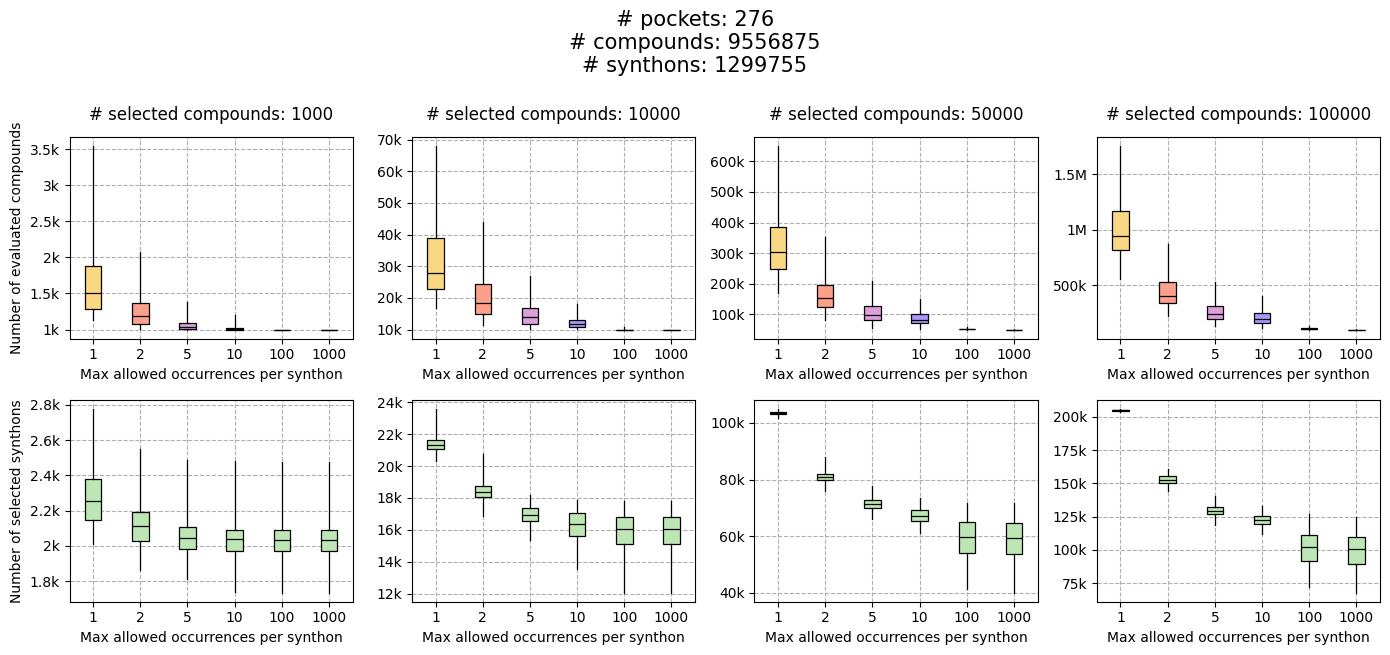

In [ ]:
MAX_MOLS = [1000, 10000, 50000, 100000]
MAX_SYNS = [1, 2, 5, 10, 100, 1000]
COLORS = ['#FAD782','#FAA08B','#DC9FDC','#AA96FA','#8DC7FA', '#D2D2D2', '#BEE6B4']

fig, ax = plt.subplots(2, 4, figsize=(3.5 * len(MAX_MOLS), 6.5))
title = f'# pockets: {len(set(RESULTS["pocket"]))}\n# compounds: {number_compounds}\n# synthons: {len(syns_counter)}'
plt.suptitle(title, size=15, y=1.0)

# Number of evaluated molecules
for c1, MAX_MOL in enumerate(MAX_MOLS):
    
    for c2, MAX_SYN in enumerate(MAX_SYNS):
        y_top = RESULTS[(RESULTS['MAX_MOL'] == MAX_MOL) & (RESULTS['MAX_SYN'] == MAX_SYN)]['eval_mols'].tolist()
        y_bottom = RESULTS[(RESULTS['MAX_MOL'] == MAX_MOL) & (RESULTS['MAX_SYN'] == MAX_SYN)]['syns'].tolist()
        simple_boxplot(ax[0][c1], c2, y_top, COLORS[c2], 0.35)
        simple_boxplot(ax[1][c1], c2, y_bottom, COLORS[-1], 0.35)
        
    ax[0][c1].set_title(f"# selected compounds: {MAX_MOL}", pad=12)
    ax[0][c1].set_xlabel("Max allowed occurrences per synthon")
    ax[0][c1].set_xticks([i for i in range(len(MAX_SYNS))], MAX_SYNS)
    ax[0][c1].grid(linestyle='--', zorder=-2)
    ax[0][c1].yaxis.set_major_formatter(ytick_fmt)

    # ax[1][c1].set_title(f"# selected compounds: {MAX_MOL}", pad=12)
    ax[1][c1].set_xlabel("Max allowed occurrences per synthon")
    ax[1][c1].set_xticks([i for i in range(len(MAX_SYNS))], MAX_SYNS)
    ax[1][c1].grid(linestyle='--', zorder=-2)
    ax[1][c1].yaxis.set_major_formatter(ytick_fmt)


# Number of captured synthons
ax[0][0].set_ylabel("Number of evaluated compounds")
ax[1][0].set_ylabel("Number of selected synthons")
plt.tight_layout()
plt.show()

In [12]:
eval_mols = RESULTS[(RESULTS['MAX_MOL'] == 100000) & (RESULTS['MAX_SYN'] == 5)]['eval_mols'].tolist()
synthons = RESULTS[(RESULTS['MAX_MOL'] == 100000) & (RESULTS['MAX_SYN'] == 5)]['syns'].tolist()

In [10]:
np.mean(eval_mols), np.median(eval_mols)

(np.float64(260097.96014492755), np.float64(239125.0))

In [13]:
np.mean(synthons), np.median(synthons)

(np.float64(129713.44565217392), np.float64(129653.5))